# Patient Recovery Prediction using Multiple Regression
### Supervised Machine Learning — Multi-Output Regression
---

## Problem Statement

A hospital wants to predict **two recovery outcomes** for patients based on their health profile and treatment plan:

| Target Variable | Description |
|---|---|
| `Recovery_Days` | Number of days until the patient is discharged |
| `Pain_Reduction_Score` | Score (0–100) indicating how much pain was reduced |

**Input Features:** Age, BMI, Blood Pressure, Therapy Hours, Medication Dosage, Pre-existing Conditions Score

**Why Multiple Regression with Two Targets?**
- Standard linear regression predicts **one** target at a time.
- `MultiOutputRegressor` wraps a base model to **independently predict each target** simultaneously.
- This is more efficient and convenient than running two separate models.

### How is this different from House Price Prediction?

| Aspect | House Price (Single Output) | Patient Recovery (Multi Output) |
|---|---|---|
| **Target** | 1 column: `Price_USD` | 2 columns: `Recovery_Days` + `Pain_Reduction_Score` |
| **y shape** | `(100,)` — 1D | `(120, 2)` — 2D |
| **Model** | `LinearRegression()` | `MultiOutputRegressor(LinearRegression())` |
| **Internally** | 1 model, 1 set of weights | 2 separate models, each learns its own weights |
| **NaN handling** | Simple fill before split | Production-safe: fill using train means only |

---

## Step 1 — Import Libraries

> We use `MultiOutputRegressor` from `sklearn.multioutput` — it wraps a base estimator
> and fits one regressor **per target column** automatically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported successfully!')

Libraries imported successfully!


---
## Step 2 — Load Dataset

> The dataset contains **120 patient records** with 6 features and **2 target variables**.
> Missing values exist in `Blood_Pressure` (5) and `Medication_Dosage` (5) — we handle them after splitting.

In [2]:
# Load the dataset
df = pd.read_csv('patient_recovery_data.csv')

# Quick overview
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Features: {df.shape[1] - 2} | Targets: 2 (Recovery_Days, Pain_Reduction_Score)")
print()
df.head(10)

Dataset shape: 120 rows x 8 columns
Features: 6 | Targets: 2 (Recovery_Days, Pain_Reduction_Score)



,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
0,58,35.5,129.0,14.3,76.3,0,67.2,0.0
1,71,19.2,71.0,16.1,76.7,4,44.7,7.7
2,48,39.7,70.0,17.9,14.8,9,77.4,0.0
3,34,34.9,117.0,7.4,90.7,8,98.7,0.0
4,62,22.0,81.0,8.1,53.0,5,64.6,0.0
5,27,17.6,138.0,2.8,NaN,0,44.8,0.0
6,40,35.8,106.0,12.0,35.4,0,61.4,0.0
7,58,33.4,101.0,1.7,90.1,1,83.5,0.0
8,77,33.9,78.0,9.8,42.0,8,94.0,0.0
9,38,34.9,88.0,11.3,6.0,2,62.9,0.0


---
## Step 3 — Exploratory Data Analysis (EDA)

> EDA helps us understand the data distribution, spot missing values, and see correlations.

In [3]:
# Check data types and missing values
print("=" * 50)
print("DATA INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()} values")

DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   120 non-null    int64  
 1   BMI                   120 non-null    float64
 2   Blood_Pressure        115 non-null    float64
 3   Therapy_Hours         120 non-null    float64
 4   Medication_Dosage     115 non-null    float64
 5   Preexisting_Score     120 non-null    int64  
 6   Recovery_Days         120 non-null    float64
 7   Pain_Reduction_Score  120 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 7.6 KB

MISSING VALUES
Age                     0
BMI                     0
Blood_Pressure          5
Therapy_Hours           0
Medication_Dosage       5
Preexisting_Score       0
Recovery_Days           0
Pain_Reduction_Score    0
dtype: int64

Total missing: 10 values


In [4]:
# Summary statistics — check ranges, means, spread
df.describe()

,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
count,120.000000,120.000000,115.000000,120.000000,115.000000,120.000000,120.000000,120.000000
mean,50.850000,28.394167,109.730435,10.008333,54.456522,4.033333,69.301667,1.687500
std,17.971336,6.627550,23.600224,5.542693,29.937312,2.936108,19.155055,4.147401
min,21.000000,17.600000,70.000000,1.300000,6.000000,0.000000,20.000000,0.000000
25%,35.750000,22.750000,91.500000,5.000000,31.550000,1.000000,58.150000,0.000000
50%,48.500000,28.650000,106.000000,10.150000,57.200000,4.000000,67.700000,0.000000
75%,66.000000,34.525000,129.000000,14.450000,80.100000,6.000000,83.825000,0.000000
max,79.000000,39.700000,159.000000,19.800000,99.300000,9.000000,113.500000,19.100000


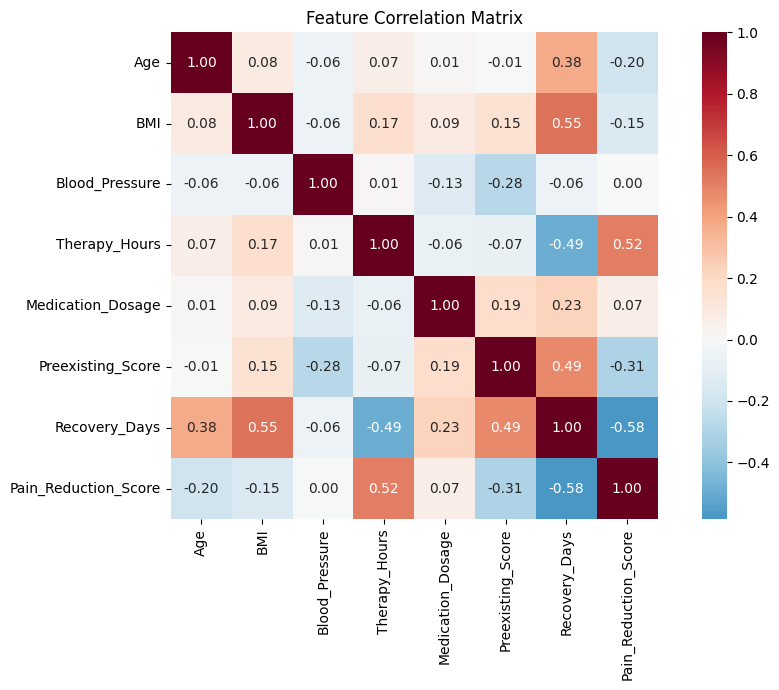

Correlation with Recovery_Days:
BMI                  0.548161
Preexisting_Score    0.485407
Age                  0.380623
Medication_Dosage    0.228464
Blood_Pressure      -0.063654
Therapy_Hours       -0.492775

Correlation with Pain_Reduction_Score:
Therapy_Hours        0.515580
Medication_Dosage    0.066017
Blood_Pressure       0.002894
BMI                 -0.146877
Age                 -0.202932
Preexisting_Score   -0.311403


In [5]:
# Correlation heatmap — which features correlate with our targets?
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Check correlation with both targets
print("Correlation with Recovery_Days:")
print(df.corr()['Recovery_Days'].drop(['Recovery_Days', 'Pain_Reduction_Score']).sort_values(ascending=False).to_string())
print("\nCorrelation with Pain_Reduction_Score:")
print(df.corr()['Pain_Reduction_Score'].drop(['Recovery_Days', 'Pain_Reduction_Score']).sort_values(ascending=False).to_string())

---
## Step 4 — Define Features & Targets

> - **X** = input features (the predictors the model learns from)
> - **y** = output targets — here we have **two columns** (multi-output)
>
> Unlike single-output regression where `y` is a 1-D array, here `y` is a **2-D DataFrame**
> with shape `(n_samples, 2)`.
>
> **Note:** We do NOT fill NaN here. We will fill them after splitting, using only training data means.

In [6]:
# Define features and targets
feature_cols = ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']
target_cols = ['Recovery_Days', 'Pain_Reduction_Score']

X = df[feature_cols]   # Shape: (120, 6) — 6 input features
y = df[target_cols]    # Shape: (120, 2) — 2 targets (this is what makes it MULTI-output)

print(f"X shape: {X.shape}  ->  {X.shape[0]} patients, {X.shape[1]} features each")
print(f"y shape: {y.shape}  ->  {y.shape[0]} patients, {y.shape[1]} target/output columns")
print(f"\nFeatures: {feature_cols}")
print(f"Targets:  {target_cols}")
print(f"\nNaN still present (will handle after split): {X.isnull().sum().sum()} missing values")

X shape: (120, 6)  ->  120 patients, 6 features each
y shape: (120, 2)  ->  120 patients, 2 target/output columns

Features: ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']
Targets:  ['Recovery_Days', 'Pain_Reduction_Score']

NaN still present (will handle after split): 10 missing values


---
## Step 5 — Train / Test Split

> We split **before** handling missing values. This is the production-safe approach.
> We reserve **20%** of data for testing and train on the remaining **80%**.
> `random_state=42` makes the split reproducible.

In [7]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients")
print(f"\nX_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  |  y_test:  {y_test.shape}")
print(f"\nNaN in X_train: {X_train.isnull().sum().sum()} | NaN in X_test: {X_test.isnull().sum().sum()}")

Training set: 96 patients
Test set:     24 patients

X_train: (96, 6)  |  y_train: (96, 2)
X_test:  (24, 6)  |  y_test:  (24, 2)

NaN in X_train: 8 | NaN in X_test: 2


---
## Step 6 — Handle Missing Values (Production-Safe Method)

> **Why we fill NaN AFTER splitting, not before:**
>
> In the house price notebook, we used `df.fillna(df.mean())` before the split.
> That was simpler but it was **data leakage** — the mean included test data.
>
> The correct approach:
> 1. Split first
> 2. Compute mean from **training data only**
> 3. Use that mean to fill NaN in both train AND test
>
> ```
> WRONG:  mean of ALL 120 patients -> includes test patients -> leakage!
> RIGHT:  mean of 96 train patients only -> test patients stay hidden
> ```

In [8]:
# Compute mean from TRAINING data only (prevents data leakage)
train_means = X_train.mean()

# Fill NaN in both sets using training means
X_train = X_train.fillna(train_means)
X_test  = X_test.fillna(train_means)   # Uses TRAIN means, not test means!

print("Training means used for filling:")
for col, val in train_means.items():
    print(f"  {col:25s}: {val:.2f}")

print(f"\nAfter filling:")
print(f"  X_train nulls: {X_train.isnull().sum().sum()}")
print(f"  X_test nulls:  {X_test.isnull().sum().sum()}")

Training means used for filling:
  Age                      : 49.65
  BMI                      : 28.62
  Blood_Pressure           : 109.60
  Therapy_Hours            : 9.81
  Medication_Dosage        : 56.42
  Preexisting_Score        : 4.31

After filling:
  X_train nulls: 0
  X_test nulls:  0


---
## Step 7 — Feature Scaling

> Features have very different ranges (Age: 21-79, Blood_Pressure: 70-159, BMI: 17-40).
> StandardScaler normalises all features to mean=0 and std=1 so no single feature dominates.
> **Rule:** Fit on training data only, transform both.

In [ ]:
# Scale features — fit on train, transform both
scaler = StandardScaler()
# Creates a scaler object — it doesn't know anything yet

X_train_scaled = scaler.fit_transform(X_train)
# fit    = calculate mean & std from training data (learns the scale)
# transform = apply the formula to every value in X_train
# fit_transform = does both in one call

X_test_scaled = scaler.transform(X_test)
# transform ONLY — uses the SAME mean & std learned from training
# does NOT re-calculate mean & std from test data (that would be leakage)

# Verify scaling worked
print("After scaling (X_train):")
print(f"  Mean per feature:  {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Std per feature:   {X_train_scaled.std(axis=0).round(2)}")
print(f"\n  All means ~ 0 and all stds ~ 1 -> scaling worked!")

After scaling (X_train):
  Mean per feature:  [-0.  0. -0.  0.  0.  0.]
  Std per feature:   [1. 1. 1. 1. 1. 1.]

  All means ~ 0 and all stds ~ 1 -> scaling worked!


---
## Step 8 — Build & Train the Multi-Output Model

> `MultiOutputRegressor(LinearRegression())` trains **one Linear Regression model per target**.
>
> Internally it fits:
> - Model A → predicts `Recovery_Days`
> - Model B → predicts `Pain_Reduction_Score`
>
> Both models share the same input features `X_train`.

In [ ]:
# Create and train the Multi-Output model
base_model = LinearRegression()
model = MultiOutputRegressor(base_model)

# Train — model learns to predict BOTH targets at once
model.fit(X_train_scaled, y_train)

# Inspect what it learned — coefficients for each target
print("Learned Coefficients:")
print("=" * 70)
for i, target in enumerate(target_cols):
    print(f"\n  Target: {target}")
    print(f"  {'-' * 50}")
    estimator = model.estimators_[i]
    for name, coef in sorted(zip(feature_cols, estimator.coef_), key=lambda x: abs(x[1]), reverse=True):
        direction = "+" if coef > 0 else "-"
        print(f"    {direction} {name:25s}  weight = {coef:>10.3f}")
    print(f"    Intercept (bias):            {estimator.intercept_:>10.3f}")

---
## Step 9 — Evaluate the Model

> We evaluate **each target separately** using three metrics:
>
> | Metric | Formula | What it means |
> |---|---|---|
> | **MAE** | avg(\|actual − predicted\|) | Average error in original units |
> | **RMSE** | √avg((actual − predicted)²) | Penalises large errors more |
> | **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |

In [ ]:
# Make predictions on test set
y_pred = model.predict(X_test_scaled)

# Evaluate each target separately
print("=" * 60)
print("        MODEL EVALUATION RESULTS")
print("=" * 60)

for i, target in enumerate(target_cols):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    
    print(f"\n  Target: {target}")
    print(f"  {'-' * 45}")
    print(f"    MAE  (Mean Absolute Error):  {mae:>10.2f}")
    print(f"    RMSE (Root Mean Sq Error):   {rmse:>10.2f}")
    print(f"    R\u00b2 Score:                    {r2:>10.4f}")
    print(f"    -> Model explains {r2*100:.1f}% of {target} variation")

print("\n" + "=" * 60)

---
## Step 10 — Visualise Actual vs Predicted

> A scatter plot of **Actual vs Predicted** values is a quick sanity check.
> Points close to the diagonal line (y = x) indicate good predictions.

In [ ]:
# Actual vs Predicted scatter plots for both targets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, target in enumerate(target_cols):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    axes[i].scatter(actual, predicted, alpha=0.7, color='steelblue', edgecolors='k', s=60)
    
    # Draw perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    axes[i].set_xlabel(f'Actual {target}')
    axes[i].set_ylabel(f'Predicted {target}')
    axes[i].set_title(f'{target}\n(R\u00b2 = {r2_score(actual, predicted):.3f})')
    axes[i].legend()

plt.suptitle('Actual vs Predicted \u2014 Multi-Output Regression', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Residual plots — are errors randomly distributed?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, target in enumerate(target_cols):
    actual = y_test.iloc[:, i].values
    predicted = y_pred[:, i]
    residuals = actual - predicted
    
    axes[i].scatter(predicted, residuals, alpha=0.7, color='coral', edgecolors='k', s=60)
    axes[i].axhline(y=0, color='black', linestyle='--', lw=1)
    axes[i].set_xlabel(f'Predicted {target}')
    axes[i].set_ylabel('Residual (Actual - Predicted)')
    axes[i].set_title(f'Residuals for {target}')

plt.suptitle('Residual Plots \u2014 Should Be Random Around Zero', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance — which features matter most for each target?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, target in enumerate(target_cols):
    importance = pd.Series(np.abs(model.estimators_[i].coef_), index=feature_cols).sort_values(ascending=True)
    importance.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='k')
    axes[i].set_xlabel('Absolute Coefficient (Weight)')
    axes[i].set_title(f'Feature Importance for {target}')

plt.suptitle('Which Features Drive Each Prediction?', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 11 — Predict on New Patient Data

> Now we use the trained model to predict outcomes for **two new patients**.
> The new data must be scaled using the **same scaler fitted on training data**.

In [ ]:
# Define two new patients
new_patients = pd.DataFrame({
    'Age'               : [45,   72  ],
    'BMI'               : [24.5, 31.2],
    'Blood_Pressure'    : [120,  145 ],
    'Therapy_Hours'     : [12,    5  ],
    'Medication_Dosage' : [50,   80  ],
    'Preexisting_Score' : [2,     7  ]
})

# Fill any missing values with training means, then scale
new_patients_filled = new_patients.fillna(train_means)
new_patients_scaled = scaler.transform(new_patients_filled)

# Predict both targets
preds = model.predict(new_patients_scaled)

# Display results
print("New Patient Predictions:")
print("=" * 70)
for i in range(len(new_patients)):
    print(f"\n  Patient {i+1}:")
    for col in feature_cols:
        print(f"    {col:25s}: {new_patients[col].iloc[i]}")
    print(f"    {'---' * 15}")
    print(f"    Predicted Recovery Days:      {preds[i, 0]:.1f} days")
    print(f"    Predicted Pain Reduction:     {preds[i, 1]:.1f}")
print("\n" + "=" * 70)

---
## Step 12 — Comparison Table (Actual vs Predicted)

In [ ]:
# Side-by-side comparison for test set
results = pd.DataFrame({
    'Actual Recovery':    y_test['Recovery_Days'].values,
    'Predicted Recovery': y_pred[:, 0].round(1),
    'Recovery Error':     (y_test['Recovery_Days'].values - y_pred[:, 0]).round(1),
    'Actual Pain':        y_test['Pain_Reduction_Score'].values,
    'Predicted Pain':     y_pred[:, 1].round(1),
    'Pain Error':         (y_test['Pain_Reduction_Score'].values - y_pred[:, 1]).round(1),
})
results.index = range(1, len(results) + 1)
results.index.name = 'Patient #'

print(results.to_string())
print(f"\nAvg Recovery Error: {results['Recovery Error'].abs().mean():.1f} days")
print(f"Avg Pain Error:     {results['Pain Error'].abs().mean():.1f} points")

---
## Summary — What We Learned

### The Complete Multi-Output ML Pipeline:

```
1. LOAD       ->  pd.read_csv()
2. EXPLORE    ->  .info(), .describe(), correlation heatmap
3. SPLIT X/y  ->  features vs targets (2 targets this time)
4. SPLIT      ->  train_test_split (80/20)
5. CLEAN      ->  fill NaN using TRAIN means only (no leakage!)
6. SCALE      ->  StandardScaler (fit on train, transform both)
7. TRAIN      ->  MultiOutputRegressor.fit()
8. PREDICT    ->  model.predict(X_test)
9. EVALUATE   ->  MAE, RMSE, R\u00b2 per target
10. VISUALIZE ->  scatter plots, residuals, feature importance
11. PREDICT   ->  new patient predictions
```

### Key Difference from House Price Notebook:

```
House Price:       df.fillna()  ->  split  ->  scale  ->  train
Patient Recovery:  split  ->  fillna(train_means)  ->  scale  ->  train
                          \u2191
                   Split FIRST, then fill = no data leakage!
```

### Key Concepts:

| Concept | What We Did |
|---|---|
| **No data leakage** | Split FIRST, then fill NaN using `X_train.mean()` only |
| **Feature scaling** | StandardScaler — fit on train, transform both |
| **Multi-output regression** | `MultiOutputRegressor` wraps any single-output model |
| **Model inspection** | Printed coefficients to understand what the model learned |
| **Visualization** | Actual vs Predicted, residual plots, feature importance |